### ファイルインポート

In [1]:
import pandas as pd
import numpy as np


In [ ]:
# --- ファイル読み込み ---
df_oof_all = pd.read_parquet("gli_oof.parquet", engine="pyarrow")
df_shap = {
    "1:STALL":pd.read_parquet("gli_shap_stall.parquet", engine="pyarrow"),
    "2:CRUISE":pd.read_parquet("gli_shap_cruise.parquet", engine="pyarrow"),
    "3:LIFT":pd.read_parquet("gli_shap_lift.parquet", engine="pyarrow")
}
df_oof_ev = pd.read_parquet("gli_oof_ev.parquet", engine="pyarrow")
df_raw = pd.read_parquet("gli_raw.parquet", engine="pyarrow")
#df_driver = pd.read_parquet("driver_driver.parquet", engine="pyarrow")
#df_features = pd.read_parquet("driver_features.parquet", engine="pyarrow")
#df_label = pd.read_parquet("driver_label.parquet", engine="pyarrow")

In [4]:
LAG=8
assets = df_raw[["^GSPC", "BAMLH0A0HYM2","ACWI", "EEM"]].dropna(how="all")
assets['next_3m_ret_sp500'] = assets["^GSPC"].pct_change(LAG).shift(-LAG)
assets['next_3m_ret_acwi'] = assets["ACWI"].pct_change(LAG).shift(-LAG)
assets['next_3m_ret_eem'] = assets["EEM"].pct_change(LAG).shift(-LAG)
assets['next_3m_diff_hy'] = assets["BAMLH0A0HYM2"].diff(LAG).shift(-LAG)
combined = pd.concat([df_oof_ev, assets[[
    'next_3m_ret_sp500', 'next_3m_ret_acwi',"next_3m_ret_eem", 'next_3m_diff_hy']]], axis=1).dropna()

print(df_oof_ev.value_counts())
stats = combined.groupby("predict_label").agg({
        'next_3m_ret_sp500': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
        'next_3m_ret_acwi': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
        'next_3m_ret_eem': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
        'next_3m_diff_hy': ['mean', 'std', 'min', 'max', "count",]
    })
pd.set_option("display.max.rows", None)
pd.set_option("display.max.columns", None)
print(stats)
combined2 = combined.loc["2021-01-01":]
stats = combined2.groupby("predict_label").agg({
        'next_3m_ret_sp500': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
        'next_3m_ret_acwi': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
        'next_3m_ret_eem': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
        'next_3m_diff_hy': ['mean', 'std', 'min', 'max', "count",]
    })
print(stats)

predict_label
2.0              341
3.0              273
1.0              120
Name: count, dtype: int64
              next_3m_ret_sp500                                      \
                           mean       std       min       max count   
predict_label                                                         
1.0                   -0.004770  0.063825 -0.236037  0.089245   120   
2.0                    0.012049  0.043688 -0.114066  0.180636   341   
3.0                    0.039484  0.033180 -0.063571  0.160344   273   

                         next_3m_ret_acwi                                      \
              <lambda_0>             mean       std       min       max count   
predict_label                                                                   
1.0             0.658333        -0.013149  0.064956 -0.243614  0.104344   120   
2.0             0.671554         0.007031  0.043262 -0.103165  0.170597   341   
3.0             0.904762         0.035940  0.032541 -0.042380  0.

C:\Users\itecc\AppData\Local\Temp\ipykernel_6680\4153608568.py:7: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat([df_oof_ev, assets[[


=== 基本統計量 ===
count    734.000000
mean       0.339625
std        0.157554
min        0.021401
25%        0.320283
50%        0.336454
75%        0.373429
max        0.830816
Name: 3:LIFT, dtype: float64


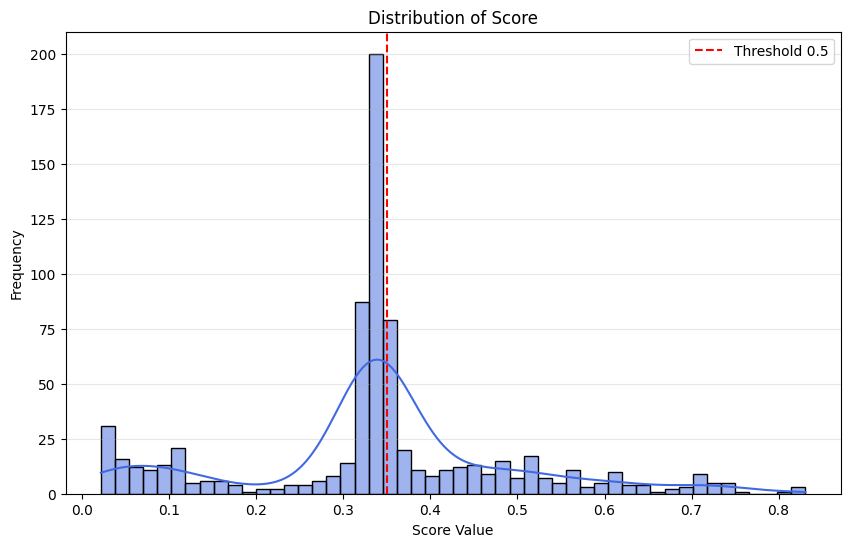

In [6]:
# 期待値のヒストグラム

import matplotlib.pyplot as plt
import seaborn as sns

df_sta1l_prob = df_oof_all["3:LIFT"]
# 1. 基本統計量の確認（平均、最小、最大、四分位数）
print("=== 基本統計量 ===")
print(df_sta1l_prob.describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_sta1l_prob, bins=50, kde=True, color='royalblue')
plt.title('Distribution of Score')
plt.xlabel('Score Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.axvline(x=0.35, color='red', linestyle='--', label='Threshold 0.5')
plt.legend()
plt.show()

In [ ]:
import numpy as np
df_sta1l_prob = df_oof_all["3:LIFT"]
df_assets = df_raw[["^GSPC", "BAMLH0A0HYM2","ACWI", "EEM"]].dropna(how="all")
df_assets['next_2m_ret_sp500'] = assets["^GSPC"].pct_change(8).shift(-8)
df_assets['next_2m_ret_acwi'] = assets["ACWI"].pct_change(8).shift(-8)
df_assets['next_2m_ret_eem'] = assets["EEM"].pct_change(8).shift(-8)
df_assets['next_2m_diff_hy'] = assets["BAMLH0A0HYM2"].diff(8).shift(-8)

# 資産データ（3ヶ月後リターン）と結合
df = pd.concat([df_sta1l_prob, df_assets], axis=1).dropna()

# バケットの定義
conditions = [
    (df['2:CRUISE'] < 0.33),
    (df['2:CRUISE'] >= 0.33) & (df['2:CRUISE'] < 0.335),
    (df['2:CRUISE'] >= 0.335)
]
labels = ['Low (Prob < 0.33)', 'Middle (0.33-0.335)', 'High (Prob >= 0.335)']
df['Stall_Bucket'] = np.select(conditions, labels, default='Unknown')

# 各バケットの統計量を算出
# ^GSPC: S&P 500, ACWI: 全世界, EEM: 新興国, HY: ハイイールド
bucket_stats = df.groupby('Stall_Bucket').agg({
    'next_3m_ret_sp500': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
    'next_3m_ret_acwi': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
    'next_3m_ret_eem': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
    'next_3m_diff_hy': ['mean', 'std', 'min', 'max', "count",]
})

pd.set_option("display.max.columns",None)
print(bucket_stats.reindex(labels))

In [ ]:
import numpy as np
df_sta1l_prob = df_oof_all["3:LIFT"]
df_assets = df_raw[["^GSPC", "BAMLH0A0HYM2","ACWI", "EEM"]].dropna(how="all")
df_assets['next_3m_ret_sp500'] = assets["^GSPC"].pct_change(8).shift(8)
df_assets['next_3m_ret_acwi'] = assets["ACWI"].pct_change(8).shift(-8)
df_assets['next_3m_ret_eem'] = assets["EEM"].pct_change(8).shift(-8)
df_assets['next_3m_diff_hy'] = assets["BAMLH0A0HYM2"].diff(8).shift(-8)

# 資産データ（3ヶ月後リターン）と結合
df = pd.concat([df_sta1l_prob, df_assets], axis=1).dropna()

# バケットの定義
conditions = [
    (df['3:LIFT'] < 0.25),
    (df['3:LIFT'] >= 0.25) & (df['3:LIFT'] < 0.45),
    (df['3:LIFT'] >= 0.45)
]
labels = ['Low (Prob < 0.25)', 'Middle (0.25-0.45)', 'High (Prob >= 0.45)']
df['Lift_Bucket'] = np.select(conditions, labels, default='Unknown')

# 各バケットの統計量を算出
# ^GSPC: S&P 500, ACWI: 全世界, EEM: 新興国, HY: ハイイールド
bucket_stats = df.groupby('Lift_Bucket').agg({
    'next_3m_ret_sp500': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
    'next_3m_ret_acwi': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
    'next_3m_ret_eem': ['mean', 'std', 'min', 'max', "count", lambda x: (x > 0).mean()],
    'next_3m_diff_hy': ['mean', 'std', 'min', 'max', "count",]
})

# カラム名を見やすく整理
bucket_stats.columns = [
    'SP500_Mean', 'SP500_WinRate', 'SampleCount',
    'ACWI_Mean', 'ACWI_WinRate',
    'EEM_Mean', 'EEM_WinRate',
    'HY_Diff_Mean'
]
print(bucket_stats.reindex(labels))

In [ ]:
START_DATE="2012-01-01"
END_DATE = "2026-01-01"
import plotly.io as pio
pio.renderers.default = "browser"   
from batch.modeling.visualize import plot_gli_diagnostic_report

df_bt = df_oof_all[["1:STALL", "2:CRUISE", "3:LIFT"]]
df_bt = pd.concat([df_bt,df_oof_ev[["predict_label"]]],axis=1)
sp500_ret = df_raw[["^GSPC"]].pct_change().dropna().rename(columns={"^GSPC":"sp500_ret"})
df_bt = df_bt.join(sp500_ret, how='inner')

plot_gli_diagnostic_report(df_bt, start_date=START_DATE, end_date=END_DATE)

In [ ]:
import plotly.io as pio
pio.renderers.default = "browser"   
from batch.modeling.visualize import _plot_graphs

_plot_graphs(df_raw["NDFACBM027SBOG"].diff(13),df_raw["gli"])

In [ ]:
lift_df = df_oof_ev[df_oof_ev["predict_label"] == 3]
lift_shap = df_shap["3:LIFT"].loc[lift_df.index]

print("\n=== SHAP平均 ===")
print(lift_shap.mean().sort_values(ascending=False).head(5))

### CRITICAL

In [ ]:
# SHAP 特徴量分析
def _da_CRITICAL_shap(df_oof_all, df_oof_ev, df_shap, df_driver):
    # ------------ 1. 分類 -------------
    # 特徴量列を追加
    df_oof_ev = df_oof_ev.join(df_driver, how='left')

    # CRITICALのみ
    critical_df = df_oof_ev[df_oof_ev['ev_rank'] == 'CRITICAL'].copy()
    critical_df = critical_df.join(df_oof_all[["1:Credit","2:Bond","3:Mix"]])
    #print(critical_df)

    # 反発と下落に分ける
    rebound_df = critical_df[critical_df['actual_return'] > 0]
    hit_df = critical_df[critical_df['actual_return'] <= 0]

    # 反発の中でも周辺のrisk_sumが低い期間を抽出 = AIのミス
    pd.set_option('display.max_rows', None)
    print(rebound_df)
    print(hit_df)
    rebound_df = rebound_df.loc["2023-10-01":"2023-10-31"]
    print("反発の中でも周辺のrisk_sumが低くマクロが壊れていない可能性が高い期間は、2023-10-01-2023-10-31")

    # ------------ 2. 犯人 -------------
    # 反発と下落でそれぞれCreditとBondの確率平均を出す
    for name, target in [("リバウンド", rebound_df), ("的中", hit_df)]:
        if not target.empty:
            p_credit = target['1:Credit'].mean()
            p_bond   = target['2:Bond'].mean()
            print(f"【{name}】の平均確率 -> Credit: {p_credit:.3f} / Bond: {p_bond:.3f}")

    # 2. どちらのレジュームが「ノイズ」を呼んでいるか？
    if rebound_df['2:Bond'].mean() > rebound_df['1:Credit'].mean():
        print("\n[診断] 反発は主に『Bond（金利急変）』由来で発生しています。")
    else:
        print("\n[診断] 反発は主に『Credit（スプレッド拡大）』由来で発生しています。")

    # ------------ 3. SHAP -------------
    rebound_indices = rebound_df.index
    rebound_shap = df_shap["1:Credit"].loc[rebound_indices]
    hit_indices = hit_df.index
    hit_shap = df_shap["1:Credit"].loc[hit_indices]

    print("\n=== 反発を誘発した特徴量 Top 5 (SHAP平均) ===")
    print(rebound_shap.mean().sort_values(ascending=False).head(5))
    print("\n=== 下落を誘発した特徴量 Top 5 (SHAP平均) ===")
    print(hit_shap.mean().sort_values(ascending=False).head(5))

    # ------------ 4. 特徴量 -------------
    features_to_analyze = [
        'VIX_z252', 'VVIX_z252', 'MOVE_z252', 'MOVE_vov', 'hy_z252',
        'SOFR_vol_spike', 'Term_Premium_z252', 'Credit_Equity_Divergence',
        'Term_Premium_diff5_z252', 'DFII10_diff5_zscore',
        'Stock_Bond_Corr_zscore', 'Equity_Gold_Ratio_zscore',
        'Flight_to_Safety_zscore', 'tlt_hy_ratio_z252'
        ]
    stats_rebound = critical_df.loc[rebound_indices, features_to_analyze].describe().T
    stats_hit    = critical_df.loc[hit_indices, features_to_analyze].describe().T

    analysis = pd.DataFrame({
        'mean_hit (Win)': stats_hit['mean'],
        'mean_rebound(Loss)': stats_rebound['mean'],
        'median_hit': stats_hit['50%'],
        'median_rebound': stats_rebound['50%']
    })

    # 差分を計算。この値が大きいほど、その指標は見分ける武器になる
    analysis['diff_mean'] = analysis['mean_hit (Win)'] - analysis['mean_rebound(Loss)']

    print(f"=== CRITICAL内部解剖レポート ===")
    print(f"下落(リターン正): {len(hit_indices)} 日")
    print(f"反発(リターン負): {len(rebound_indices)} 日")
    print("-" * 50)
    print(analysis.sort_values('diff_mean', key=abs, ascending=False))

In [ ]:
# フィルター
def _da_CRITICAL_filter(df_oof_all, df_oof_ev, df_shap, df_driver):

    df_oof_ev = df_oof_ev.join(df_driver, how='left')
    mask_target = (df_oof_ev['ev_rank'] == 'CRITICAL') & (df_oof_ev['Credit_Equity_Divergence'] <= 1.0)
    mask_rebound = (df_oof_ev['ev_rank'] == 'CRITICAL') & (df_oof_ev['Credit_Equity_Divergence'] > 1.0)
    features = [
        'VIX_z252', 'VVIX_z252', 'MOVE_z252', 'MOVE_vov', 'hy_z252',
        'SOFR_vol_spike', 'Term_Premium_z252', 'Credit_Equity_Divergence',
        'Term_Premium_diff5_z252', 'DFII10_diff5_zscore',
        'Stock_Bond_Corr_zscore', 'Equity_Gold_Ratio_zscore',
        'Flight_to_Safety_zscore', 'tlt_hy_ratio_z252'
        ]
    stats_target = df_oof_ev.loc[mask_target, features].describe().T
    stats_rebound = df_oof_ev.loc[mask_rebound, features].describe().T
    
    comparison = stats_target[['mean', '50%']].join(
        stats_rebound[['mean', '50%']], 
        lsuffix='_Target(21d)', 
        rsuffix='_Rebound(37d)'
    )
    comparison['diff_mean'] = comparison['mean_Target(21d)'] - comparison['mean_Rebound(37d)']
    print("=== 的中(21日) vs リバウンド(37日) 特徴量比較レポート ===")
    print(comparison.sort_values('diff_mean', key=abs, ascending=False))

### バックテスト

In [ ]:
# バックテスト
def calc_mdd(cum_series):
    dd = (cum_series / cum_series.cummax() - 1)
    mdd = dd.min()
    mdd_idx = dd.idxmin()
    return mdd, mdd_idx

def _cal_driver_signal(df_oof_ev,df_oof_all,df_daily,START_DATE,END_DATE):
    # 1. データ準備とラグの処理
    df_bt = df_oof_ev.join(df_oof_all, how='left').sort_index().copy()
    sp500_ret = df_daily["^GSPC"].pct_change().dropna().rename("sp500_ret")
    df_bt = df_bt.join(sp500_ret, how='left').sort_index().copy()
    df_bt = df_bt.loc[START_DATE:END_DATE]

    # 2-1. ロジックA Credit単独(>0.4) または Hybrid Risk Score(>0.6)
    credit_threshold = 0.4
    hybrid_threshold = 0.6
    df_bt['risk_score'] = df_bt['1:Credit'] + (df_bt['2:Bond'] * 0.5)
    df_bt['macro_danger'] = (
        (df_bt['ev_rank'].isin(['CRITICAL', 'High Risk'])) & 
        ((df_bt['1:Credit'] > credit_threshold) | (df_bt['risk_score'] > hybrid_threshold))
    )

    # 2-2. ロジックB - ロジックAにパラシュート追加（価格アクションによる緊急回避）
    # 直近5日のボラティリティに対して-2.0倍の急落を検知
    #df_bt['vol_5d'] = df_bt['sp500_ret'].rolling(5).std()
    #df_bt['vol_5d'] = df_bt['sp500_ret'].shift(1).rolling(5).std()
    vol_clean = sp500_ret.rolling(5).std().rename("vol_5d")
    df_bt = df_bt.join(vol_clean, how='left')
    df_bt['price_crash'] = df_bt['sp500_ret'] < (-2.0 * df_bt['vol_5d'])

    # 「マクロの地盤が緩んでいる（Caution以上）」かつ「価格が急落」した場合のみパラシュート
    #df_bt['parachute_active'] = (df_bt['risk_sum'] > hybrid_threshold) & df_bt['price_crash']
    df_bt['risk_sum'] = df_bt['1:Credit'] + df_bt["2:Bond"]
    df_bt['parachute_active'] = (df_bt['risk_sum'] > 0.5) & df_bt['price_crash']
    
    return df_bt

def _back_test(df_daily, df_oof_ev, df_oof_all,START_DATE,END_DATE):

    df_bt = _cal_driver_signal(df_oof_ev,df_oof_all,df_daily,START_DATE,END_DATE)

    # --- 戦略リターンの計算 (シグナルのラグ) ---
    results_return = []
    results_mdd = []
    results_mdd_idx =[]
    for lag in range(21):

        # 前日の終値で出た判定（ev_rank）を、今日のリターン（sp500_ret）に適用する
        #signal = df_bt['ev_rank'].shift(lag)
        basic_signal = df_bt['macro_danger'].shift(lag).fillna(False)
        parachute_signal = df_bt['parachute_active'].shift(1).fillna(False)
        df_bt['rtm_signal'] = basic_signal | parachute_signal

        # 昨日のシグナルがCRITICALなら、今日のリターンは0（現金退避）
        return_strategy = np.where(
            #signal.isin(danger_ranks),
            #basic_signal,
            #parachute_signal,
            df_bt['rtm_signal'],
            0.0,
            df_bt['sp500_ret']
        )
        return_strategy = pd.Series(return_strategy, index=df_bt.index)
        # 3. 累積リターンの計算
        cum_strategy  = (1 + return_strategy.fillna(0)).cumprod()
        mdd_strategy, mdd_idx = calc_mdd(cum_strategy)
        results_return.append(cum_strategy)
        results_mdd.append(mdd_strategy)
        results_mdd_idx.append(mdd_idx)

    df_strategy_return = pd.concat(results_return, axis=1)
    df_strategy_return.columns = [f"lag_{i}" for i in range(21)]
    df_strategy_mdd = pd.Series(results_mdd, index=[f"lag_{i}" for i in range(21)])
    df_strategy_mdd_idx = pd.Series(results_mdd_idx, index=[f"lag_{i}" for i in range(21)])

    df_bt['cum_benchmark'] = (1 + df_bt['sp500_ret'].fillna(0)).cumprod()
    mdd_bench, mdd_bench_idx = calc_mdd(df_bt['cum_benchmark'])

    print("=== 現実的バックテスト結果（lag sweep） ===")
    print(f"{START_DATE}～{END_DATE}")
    print(
        f"Buy & Hold 最終: {df_bt['cum_benchmark'].iloc[-1]:.2f}倍 "
        f"/ MDD: {mdd_bench:.1%} (at {mdd_bench_idx})"
    )
    print(f"パラシュート検知数: {df_bt['parachute_active'].sum()}")
    print(f"RTM Strategy  リターン:")
    final_returns = df_strategy_return.iloc[-1]

    summary = pd.DataFrame({
        "lag": range(21),
        "final_return": df_strategy_return.iloc[-1].values,
        "MDD": df_strategy_mdd.values,
        "MDD_date": df_strategy_mdd_idx
    }).set_index("lag")

    print(summary.sort_values("final_return", ascending=False).sort_index())

    # shift(1) で発生する NaN を False で埋めることでエラーを回避
    mask = df_bt['parachute_active'].shift(1).fillna(False)
    # 損失（sp500_retがマイナス）を回避した順にソート
    rescue_log = df_bt[mask].sort_index()

    # 回避した損失が特に大きい「ワースト10」を表示
    print("=== RTM パラシュート救済リスト（回避した損失のワースト10） ===")
    # 回避できたはずのマイナスリターン（sp500_ret）が深い順に表示
    print(rescue_log[['sp500_ret', '1:Credit', '2:Bond', 'risk_sum', 'risk_score']].sort_values('sp500_ret'))
    
    import plotly.io as pio
    pio.renderers.default = "browser"   
    from batch.modeling.visualize import plot_index
    plot_index(summary)
